
# IFRS 9 — PIT PD Calibration with Macro Forecasting & Scenario Overlay (Pure Python, v3)

This version fixes the **NaN merges** by building a **unified monthly macro path** that stitches **history + only-as-much forecast as needed** to cover **every account × horizon month**.

**Pipeline**  
1) Load & robustly map columns (auto-build a *proxy PD* if `pit_pd_12m` is absent).  
2) PD safety + logit, portfolio diagnostics.  
3) CIL & Platt calibration.  
4) Macro overlay logistic model on historical data.  
5) Anchors & horizons (per-account).  
6) **Unified macro path** (history + enough SARIMAX forecasts to cover horizons).  
7) Scenarios (Baseline/ Upside/ Downside) on the unified path.  
8) Merge, score macro overlay, scenario-weighted PDs, final 12M table.  

**Input:** `/mnt/data/ifrs9_pit_pd_intro_final.csv`  
**Outputs:** `final_12m_python.csv`  


In [2]:

import pandas as pd
import numpy as np
import warnings
from pathlib import Path

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Scikit-learn for proxy PD (if pit_pd_12m missing)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from pandas.tseries.frequencies import to_offset
from pandas.tseries.offsets import MonthBegin

import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

DATA_PATH = Path("C:/Users/customer/Desktop/MyVideos/UDEMY LESSONS/IFRS 9 Python/Module 5/ifrs9_pit_pd_intro_final.csv")
assert DATA_PATH.exists(), f"Input file not found at: {DATA_PATH}"


## 1) Load data, map columns, and (if needed) derive a proxy PD

In [4]:

df = pd.read_csv(DATA_PATH)

def find_col(candidates, cols):
    for c in candidates:
        if c in cols:
            return c
    low = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in low:
            return low[c.lower()]
    return None

cols = df.columns.tolist()

col_account   = find_col(["account_id","acct_id","id"], cols) or "account_id"
col_date      = find_col(["report_date","report_dt","date","as_of_date","reporting_date"], cols) or "report_date"
col_pd_opt    = find_col(["pit_pd_12m","pd_12m","pd","pit_pd"], cols)  # optional
col_default   = find_col(["default_flag","default","event","y"], cols) or "default_flag"

col_gdp   = find_col(["macro_gdp_growth","gdp","gdp_growth"], cols) or "macro_gdp_growth"
col_unemp = find_col(["macro_unemployment","unemployment","unemp"], cols) or "macro_unemployment"
col_rate  = find_col(["macro_interest_rate","interest_rate","rate"], cols) or "macro_interest_rate"

# Ensure must-haves exist
must_have = [col_account, col_date, col_default, col_gdp, col_unemp, col_rate]
missing_must = [c for c in must_have if c not in df.columns]
if missing_must:
    raise ValueError(f"Missing required columns: {missing_must}\nAvailable: {df.columns.tolist()}")

# Parse dates and sort
df[col_date] = pd.to_datetime(df[col_date], errors="coerce")
df = df.dropna(subset=[col_date]).copy()
df = df.sort_values(col_date).reset_index(drop=True)

# If no PIT PD present, create a proxy via chronological split + LogisticRegression
if col_pd_opt is None or col_pd_opt not in df.columns:
    numeric_candidates = ["loan_age_m","credit_utilization","dpd","internal_score","age","EAD","LGD","dependents"]
    cat_candidates     = ["employment_status","marital_status","region","stage"]
    num_feats = [c for c in numeric_candidates if c in df.columns]
    cat_feats = [c for c in cat_candidates if c in df.columns]

    # If default flag has variation, fit proxy; otherwise fall back to a ranked score
    if df[col_default].dropna().nunique() >= 2 and (len(num_feats)+len(cat_feats) > 0):
        split_date = df[col_date].quantile(0.70)
        tr = df[df[col_date] <= split_date].copy()

        pre = ColumnTransformer([
            ("num", StandardScaler(), num_feats),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)
        ], remainder="drop")

        X_tr = tr[num_feats + cat_feats].copy()
        y_tr = tr[col_default].astype(int).values

        clf = Pipeline([
            ("pre", pre),
            ("lr", LogisticRegression(max_iter=200, class_weight="balanced", solver="lbfgs"))
        ])
        clf.fit(X_tr, y_tr)

        X_all = df[num_feats + cat_feats].copy()
        pd_proxy = clf.predict_proba(X_all)[:,1]
        df["pit_pd_12m"] = np.clip(pd_proxy, 1e-7, 1-1e-7)
    else:
        # Fallback: scaled rank of best available column or mean default rate
        base = None
        for c in ["internal_score","credit_utilization","dpd"]:
            if c in df.columns:
                base = c; break
        if base is not None:
            s = pd.to_numeric(df[base], errors="coerce")
            r = (s.rank(method="average") - 1) / (s.notna().sum()-1)
            df["pit_pd_12m"] = np.clip(r.fillna(r.mean()).values, 1e-7, 1-1e-7)
        else:
            prior = float(df[col_default].mean()) if df[col_default].notna().any() else 0.05
            df["pit_pd_12m"] = np.clip(prior, 1e-7, 1-1e-7)
else:
    df.rename(columns={col_pd_opt: "pit_pd_12m"}, inplace=True)

# Keep essentials
essential_cols = [col_account, col_date, "pit_pd_12m", col_default, col_gdp, col_unemp, col_rate]
df = df[essential_cols].copy()


## 2) PD safety & logit + quick portfolio metrics

In [6]:

EPS = 1e-7
df["pd_raw"] = np.clip(df["pit_pd_12m"].astype(float), EPS, 1-EPS)
df["logit_pd_raw"] = np.log(df["pd_raw"] / (1.0 - df["pd_raw"]))
df["default_flag"] = df[col_default].astype(int)

n = df.shape[0]
mean_pd = df["pd_raw"].mean()
obs_dr  = df["default_flag"].mean()
eo_ratio = (obs_dr / mean_pd) if mean_pd > 0 else np.nan
brier = np.mean((df["pd_raw"] - df["default_flag"])**2)

metrics = pd.DataFrame({
    "n":[n],
    "mean_pd":[mean_pd],
    "obs_dr":[obs_dr],
    "eo_ratio":[eo_ratio],
    "brier":[brier]
})
metrics


,n,mean_pd,obs_dr,eo_ratio,brier
0,5000,0.49306,0.4686,0.950392,0.193442


## 3) Calibration (CIL & Platt)

In [8]:

y = df["default_flag"].values
offset = df["logit_pd_raw"].values

# CIL
cil_mod = sm.GLM(y, np.ones((len(y),1)), family=sm.families.Binomial(), offset=offset)
cil_res = cil_mod.fit()
df["pd_cil"] = np.clip(cil_res.fittedvalues, EPS, 1-EPS)

# Platt
X_platt = sm.add_constant(df["logit_pd_raw"])
platt_mod = sm.Logit(y, X_platt)
platt_res = platt_mod.fit(disp=False)
df["pd_platt"] = np.clip(platt_res.predict(X_platt), EPS, 1-EPS)

df[[col_account, col_date, "pd_raw", "pd_cil", "pd_platt"]].head()


,account_id,report_date,pd_raw,pd_cil,pd_platt
0,9527835,2022-01-01,0.322096,0.294891,0.296955
1,6967520,2022-01-01,0.181943,0.163717,0.166373
2,2849396,2022-01-01,0.758532,0.734399,0.731777
3,9749917,2022-01-01,0.608152,0.577364,0.576217
4,1308617,2022-01-01,0.474574,0.442905,0.443394


## 4) Macro overlay logistic model (fit on historical data)

In [10]:

X_hist = pd.DataFrame({
    "const": 1.0,
    "logit_pd_raw": df["logit_pd_raw"].values,
    "gdp": df[col_gdp].values,
    "unemp": df[col_unemp].values,
    "rate": df[col_rate].values
})
y_hist = df["default_flag"].values

macro_logit = sm.Logit(y_hist, X_hist).fit(disp=False)
macro_logit.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4995
Method:                           MLE   Df Model:                            4
Date:                Thu, 13 Nov 2025   Pseudo R-squ.:                  0.1810
Time:                        02:52:46   Log-Likelihood:                -2830.3
converged:                       True   LL-Null:                       -3455.9
Covariance Type:            nonrobust   LLR p-value:                1.287e-269
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.4973      0.230     -2.163      0.031      -0.948      -0.047
logit_pd_raw     0.9871      0.033     30.241      0.000       0.923       1.051
gdp              0.0140      0.032      0.443      0.658      -0.048       0.076
unemp            0.0804      0.022      3.733      0.000       0.038       0.123
rate            -0.0198      0.064     -0.309      0.757      -0.145       0.106
================================================================================
"""

## 5) Anchors per account & horizon expansion

In [12]:

anchors = (
    df.sort_values([col_account, col_date])
      .groupby(col_account, as_index=False)
      .agg(anchor_dt=(col_date, "max"),
           pd_raw_anchor=("pd_raw","last"))
)

fc_months = 12  # change if you need other horizons

rows = []
for _, r in anchors.iterrows():
    for h in range(1, fc_months+1):
        fc_dt = (r["anchor_dt"] + to_offset(f"{h}M")).to_period("M").to_timestamp()
        rows.append((r[col_account], h, fc_dt, r["pd_raw_anchor"]))
acct_h = pd.DataFrame(rows, columns=[col_account, "horizon_m", "fc_dt", "pd_raw"])
acct_h.head()


,account_id,horizon_m,fc_dt,pd_raw
0,1000917,1,2023-03-01,0.530895
1,1000917,2,2023-04-01,0.530895
2,1000917,3,2023-05-01,0.530895
3,1000917,4,2023-06-01,0.530895
4,1000917,5,2023-07-01,0.530895


## 6) Unified macro path (history + just-enough forecasts to cover ALL horizons)

In [14]:

# Monthly macro history from dataset
macro_hist = (
       .rename(columns={col_gdp: "gdp", col_unemp: "unemp", col_rate: "rate"})
)   df.groupby(pd.Grouper(key=col_date, freq="MS"))[[col_gdp, col_unemp, col_rate]]
      .mean()


# Normalize to MonthStart
macro_hist.index = macro_hist.index.to_period("M").to_timestamp()

# Range needed from horizons
min_needed = acct_h["fc_dt"].min().to_period("M").to_timestamp()
max_needed = acct_h["fc_dt"].max().to_period("M").to_timestamp()

# Determine last observed macro month with complete row
last_obs = macro_hist.dropna().index.max()
if pd.isna(last_obs):
    raise ValueError("No macro history available to train forecasts.")

def fit_forecast_series(series, steps):
    series = series.dropna().asfreq("MS")
    model = SARIMAX(series, order=(1,0,0), trend="c",
                    enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    fc = res.get_forecast(steps=steps)
    return fc.summary_frame()["mean"]

# How many months of forecast do we need beyond last_obs?
if max_needed <= last_obs:
    steps = 0
else:
    steps = len(pd.date_range(start=last_obs + MonthBegin(1), end=max_needed, freq="MS"))

# Forecast table
if steps > 0:
    gdp_fc   = fit_forecast_series(macro_hist["gdp"],   steps)
    unemp_fc = fit_forecast_series(macro_hist["unemp"], steps)
    rate_fc  = fit_forecast_series(macro_hist["rate"],  steps)

    macro_fc = pd.concat([gdp_fc, unemp_fc, rate_fc], axis=1)
    macro_fc.columns = ["gdp", "unemp", "rate"]
    macro_fc.index.name = "dt"
else:
    macro_fc = pd.DataFrame(columns=["gdp","unemp","rate"])

# Build continuous month index and combine
target_months = pd.date_range(start=min_needed, end=max_needed, freq="MS")
macro_path = macro_hist.reindex(target_months)
macro_path = macro_path.combine_first(macro_fc)
macro_path.index.name = "dt"

print("Macro path coverage:", macro_path.index.min().date(), "→", macro_path.index.max().date())
print("Needed range       :", min_needed.date(), "→", max_needed.date())


Macro path coverage: 2022-01-01 → 2025-11-01
Needed range       : 2022-01-01 → 2025-11-01


## 7) Scenarios on unified path and merge with horizons

In [16]:

w_baseline, w_up, w_down = 0.60, 0.20, 0.20
shock_up   = {"gdp": +0.50, "unemp": -0.30, "rate": -0.25}
shock_down = {"gdp": -1.00, "unemp": +0.50, "rate": +0.50}

def apply_shock(df_fc, shock):
    out = df_fc.copy()
    for k, v in shock.items():
        out[k] = out[k] + v
    return out

base = macro_path.copy(); base["scen_name"] = "Baseline"; base["weight"] = w_baseline
up   = apply_shock(macro_path, shock_up);   up["scen_name"]   = "Upside";   up["weight"]   = w_up
down = apply_shock(macro_path, shock_down); down["scen_name"] = "Downside"; down["weight"] = w_down

macro_fc_all = pd.concat([base, up, down]).reset_index()  # dt becomes a column
macro_fc_all = macro_fc_all[["dt","scen_name","weight","gdp","unemp","rate"]]

# Merge
cart = acct_h.merge(macro_fc_all, left_on="fc_dt", right_on="dt", how="left")
miss_share = cart["dt"].isna().mean()
print(f"Share of missing macro matches after unified path: {miss_share:.2%}")
cart.head()


Share of missing macro matches after unified path: 0.00%


,account_id,horizon_m,fc_dt,pd_raw,dt,scen_name,weight,gdp,unemp,rate
0,1000917,1,2023-03-01,0.530895,2023-03-01,Baseline,0.6,2.004744,4.972436,2.982372
1,1000917,1,2023-03-01,0.530895,2023-03-01,Upside,0.2,2.504744,4.672436,2.732372
2,1000917,1,2023-03-01,0.530895,2023-03-01,Downside,0.2,1.004744,5.472436,3.482372
3,1000917,2,2023-04-01,0.530895,2023-04-01,Baseline,0.6,2.052479,5.202314,3.012645
4,1000917,2,2023-04-01,0.530895,2023-04-01,Upside,0.2,2.552479,4.902314,2.762645


## 8) Score macro overlay per scenario and aggregate

In [18]:

EPS = 1e-7
cart["pd_raw"] = np.clip(cart["pd_raw"], EPS, 1-EPS)
cart["logit_pd_raw"] = np.log(cart["pd_raw"]/(1.0 - cart["pd_raw"]))

X_sc = pd.DataFrame({
    "const": 1.0,
    "logit_pd_raw": cart["logit_pd_raw"].values,
    "gdp": cart["gdp"].values,
    "unemp": cart["unemp"].values,
    "rate": cart["rate"].values
})
prob_adj = macro_logit.predict(X_sc)
cart["pd_scen"] = np.clip(prob_adj, EPS, 1-EPS)

# Scenario-weighted PD per account × horizon
pd_weighted = (
    cart.groupby([col_account, "horizon_m"], as_index=False)
        .apply(lambda g: pd.Series({"pd_weighted": float((g["weight"]*g["pd_scen"]).sum())}))
        .reset_index(drop=True)
)

# Latest record per account for comparison
latest_idx = df.groupby(col_account)[col_date].idxmax()
latest = df.loc[latest_idx, [col_account, "default_flag", "pd_raw", "pd_cil", "pd_platt"]].copy()

final_12m = latest.merge(pd_weighted[pd_weighted["horizon_m"]==12][[col_account,"pd_weighted"]],
                         on=col_account, how="left")
final_12m = final_12m.rename(columns={"pd_weighted":"pd_macro_weighted_12m"})
final_12m.head()


,account_id,default_flag,pd_raw,pd_cil,pd_platt,pd_macro_weighted_12m
0,1000917,0,0.530895,0.499037,0.498836,0.497397
1,1004138,1,0.840712,0.822874,0.819969,0.817226
2,1017297,1,0.372043,0.342752,0.344372,0.341782
3,1019477,0,0.204292,0.184332,0.186978,0.185332
4,1019675,1,0.651662,0.622169,0.620521,0.618080


## 9) Save outputs

In [20]:

out_csv = Path("/mnt/data/final_12m_python.csv")
final_12m.to_csv(out_csv, index=False)
out_csv, final_12m.shape


(WindowsPath('/mnt/data/final_12m_python.csv'), (5000, 6))

### (Optional) Quick plots

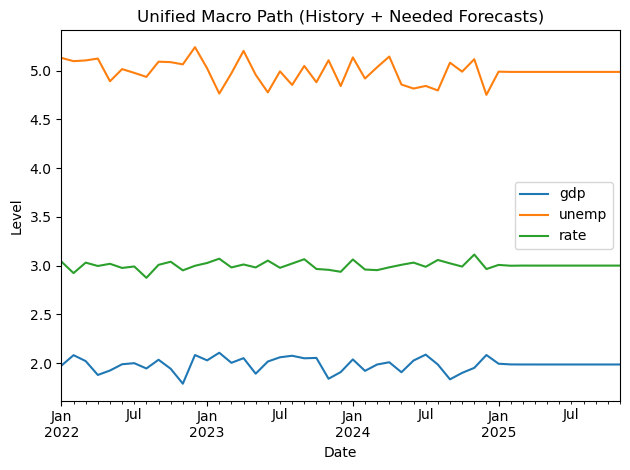

In [22]:

macro_path.plot(title="Unified Macro Path (History + Needed Forecasts)")
plt.xlabel("Date"); plt.ylabel("Level"); plt.tight_layout(); plt.show()
